<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SARSA con Políticas epsilon_greedy**

SARSA TIENE UN BUCLE DIFERENTE QUE EL RESTO POR EL HECHO DE TENER QUE TENER LA ACCION ACTUAL Y LA FUTURA, PERO POCO CAMBIO

In [1]:
%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'
!pip install "gymnasium[toy-text]
!pip install "gymnasium[box2d]

In [2]:
import sys

if "google.colab" in sys.modules:
    print("Google Colab")
    !git clone #TODO
    %cd k_brazos/PATH_CLONADO #TODO

sys.path.append("src")
print(sys.path)

['C:\\Users\\Alberto\\anaconda3\\envs\\EML\\python311.zip', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\DLLs', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML', '', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib\\site-packages', 'src']


In [3]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
from agent.sarsa_semi_gradient import SemiGradientSARSA
from plotting import plot_stats, plot_episode_lengths
from IPython.display import clear_output
import time
import random

In [4]:
seed = 123 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla
random.seed(seed) # semilla del generador aleatorio

In [5]:
# continuous=False para que el output sea discreto
# enable_wind = True para que haya mayor dificultad en la navegación
env = gym.make("LunarLander-v3", render_mode="rgb_array", continuous=False, gravity=-10.0, enable_wind=True, wind_power=2.5, turbulence_power=0)

num_episodes = 1500

sg_sarsa_agent = SemiGradientSARSA(env=env, learning_rate=0.0005, initial_epsilon=1.0, epsilon_decay=0.001, final_epsilon=0.05, discount_factor=0.99)


episode_lengths = []
list_stats = []

for episode in tqdm(range(num_episodes)):
    state, _ = env.reset(seed=seed)

    action = sg_sarsa_agent.get_action(state)
    
    done = False
    
    episode_reward = 0
    episode_length = 0
    
    while not done:
        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        if not done:
            next_action = sg_sarsa_agent.get_action(next_state)
        else:
            next_action = None
        
        sg_sarsa_agent.update(state, next_state, action, next_action, reward, terminated, truncated)
        state = next_state
        action = next_action
        
        episode_reward += reward
        episode_length += 1
    
    # Fin de episodio
    sg_sarsa_agent.end_episode()
    sg_sarsa_agent.decay_exploration()

    # Se guardan los promedios y la longitud del episodio para las gráficas posteriores
    list_stats.append(episode_reward)
    episode_lengths.append(episode_length)

    if episode % 50 == 0 and episode != 0:
        print(f"Recompensa del episodio: {episode_reward:.2f}, epsilon: {sg_sarsa_agent.epsilon:.3f}")

  3%|██▋                                                                             | 51/1500 [00:11<05:19,  4.54it/s]

Recompensa del episodio: -129.40, epsilon: 0.949


  7%|█████▎                                                                         | 101/1500 [00:22<05:05,  4.57it/s]

Recompensa del episodio: -166.66, epsilon: 0.899


 10%|███████▉                                                                       | 151/1500 [00:34<05:02,  4.45it/s]

...

 93%|████████████████████████████████████████████████████████████████████████▊     | 1401/1500 [23:32<01:00,  1.63it/s]

Recompensa del episodio: 280.89, epsilon: 0.050


 97%|███████████████████████████████████████████████████████████████████████████▍  | 1451/1500 [24:22<00:54,  1.12s/it]

Recompensa del episodio: 249.98, epsilon: 0.050


100%|██████████████████████████████████████████████████████████████████████████████| 1500/1500 [25:03<00:00,  1.00s/it]


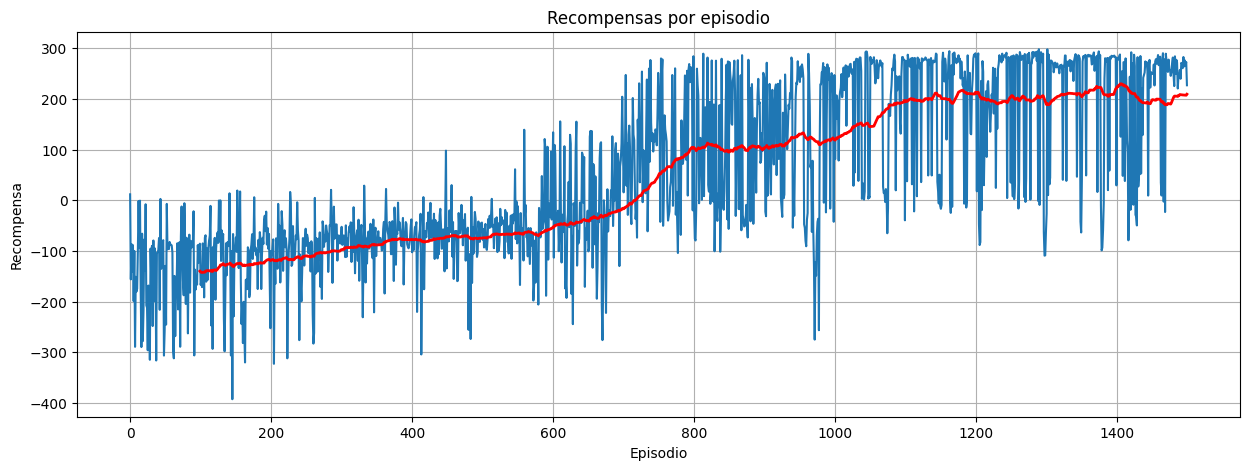

Máxima proporcion: 298.2687970128694


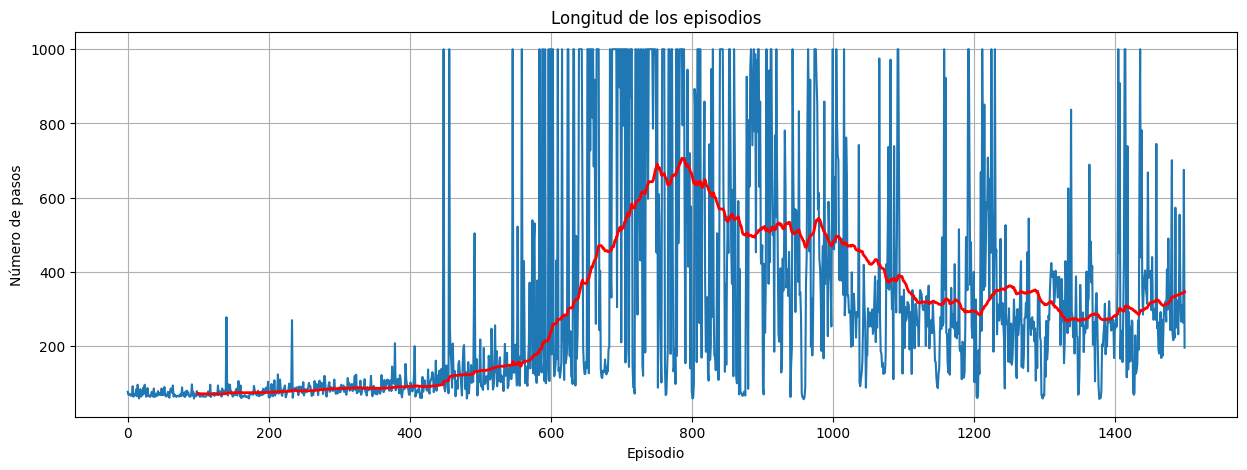

In [6]:
plot_stats(list_stats)
print(f"Máxima proporcion: {max(list_stats)}")
plot_episode_lengths(episode_lengths)

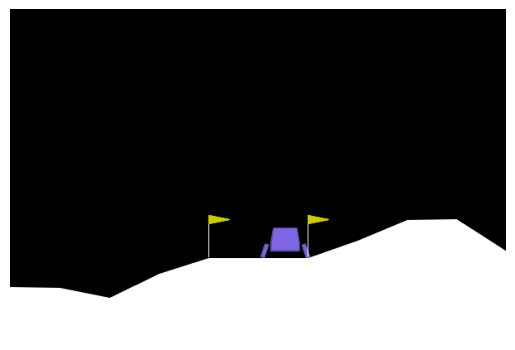

Reward final:273.43
Acciones: FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIR

In [7]:
state, _ = env.reset(seed=seed)
ACTION_NAMES = {0: "DO_NOTHING", 1: "FIRE_MAIN_ENGINE", 2: "FIRE_LEFT_ENGINE", 3: "FIRE_RIGHT_ENGINE"}

actions_taken = []

done = False
rewards = 0

while not done:
    frame = env.render()

    clear_output(wait=True)
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

    action = sg_sarsa_agent.get_action(state, training=False) # training False asegura np.argmax(self.q_values[state])
    actions_taken.append(ACTION_NAMES[action])

    state, reward, terminated, truncated, _ = env.step(action)
    rewards += reward

    done = terminated or truncated

    time.sleep(0.01)

print(f"Reward final:{rewards:.2f}")
print("Acciones:", " -> ".join(actions_taken))